# 🚶 Locomotion Mode Detection — End-to-End Pipeline

**Goal:** Classify a person's movement state from raw smartphone IMU data into three classes:

| Class | Definition | Example |
|-------|-----------|--------|
| 🧍 **Stationary** | No movement | Sitting at desk, standing in queue |
| 🚶 **On Foot** | Self-propelled body motion | Walking, running |
| 🚗 **In Vehicle** | Passive motorized transport | Car, bus, train |

**Why this framing?** These classes reflect the *kinematic source* of motion, not the activity itself. This is exactly how Google Activity Recognition API and Apple CMMotionActivity frame it — because the physics is unambiguous:
- On Foot → body generates rhythmic motion
- In Vehicle → environment generates aperiodic vibration
- Stationary → neither

---

## Architecture Overview

```
iPhone Sensors (Phyphox app)
  ├── Accelerometer    (gravity + motion)
  ├── Gyroscope        (rotation rate — key for step cadence)
  ├── Linear Accel     (gravity-removed — key for Still vs Vehicle)
  └── Magnetometer     (compass / orientation)
         │
         ▼  stream over WiFi (HTTP API)
  Collect 5-second window  →  resample to 100 pts @ 20Hz
         │
         ▼
  Feature Extraction  →  216-dim vector
  (time-domain + frequency-domain per channel)
         │
         ▼
  XGBoost Classifier  →  [P(Stat), P(Foot), P(Veh)]
         │
         ▼
  GPS Bayesian Fusion  →  scale probs by speed likelihood
         │
         ▼
  Probability Averaging (5 windows)  →  confidence-weighted smooth
         │
         ▼
  Confidence Gate (< 45% → hold state)
         │
         ▼
  Final Label + Confidence
```

In [ ]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install xgboost lightgbm imbalanced-learn scipy matplotlib seaborn -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats, signal as sp_signal

# plot style
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.size':        11,
})

CLASS_COLORS = {'Stationary': '#58a6ff', 'On Foot': '#3fb950', 'In Vehicle': '#f78166'}
CLASS_NAMES  = ['Stationary', 'On Foot', 'In Vehicle']
FS = 20   # Hz — target sample rate
WINDOW_SIZE = 100  # 5 seconds × 20 Hz

print('Setup complete.')

Setup complete.


## 1. What Does Each Class Look Like?

Before any ML, let's understand the *physics* of each class in the raw sensor signals.

We'll generate realistic synthetic IMU windows that capture the key characteristics:
- **Stationary**: near-zero motion, gravity dominates accelerometer
- **On Foot**: ~1.5 Hz periodic bounce (step cadence), rhythmic gyroscope rotation
- **In Vehicle**: aperiodic road/engine vibration (~5-15 Hz), stable gravity vector

In [ ]:
rng = np.random.default_rng(42)
t   = np.linspace(0, 5, WINDOW_SIZE)  # 5 seconds

def make_window(cls, seed=0):
    rng = np.random.default_rng(seed)
    if cls == 'Stationary':
        acc  = np.stack([rng.normal(0, 0.05, WINDOW_SIZE),
                         rng.normal(0, 0.05, WINDOW_SIZE),
                         9.8 + rng.normal(0, 0.05, WINDOW_SIZE)], axis=1)
        gyro = rng.normal(0, 0.01, (WINDOW_SIZE, 3))
        lin  = rng.normal(0, 0.05, (WINDOW_SIZE, 3))

    elif cls == 'On Foot':
        step_freq = 1.7  # Hz — typical walking cadence
        phase = rng.uniform(0, 2*np.pi)
        bounce = 2.5 * np.sin(2*np.pi*step_freq*t + phase)
        acc  = np.stack([
            0.8*np.sin(2*np.pi*step_freq*t + phase + 0.5) + rng.normal(0, 0.3, WINDOW_SIZE),
            0.5*np.sin(2*np.pi*step_freq*2*t)             + rng.normal(0, 0.2, WINDOW_SIZE),
            bounce + 9.8                                  + rng.normal(0, 0.3, WINDOW_SIZE),
        ], axis=1)
        gyro = np.stack([
            0.6*np.sin(2*np.pi*step_freq*t + phase) + rng.normal(0, 0.05, WINDOW_SIZE),
            0.3*np.sin(2*np.pi*step_freq*t)         + rng.normal(0, 0.05, WINDOW_SIZE),
            0.2*np.sin(2*np.pi*step_freq*t + 1.0)   + rng.normal(0, 0.05, WINDOW_SIZE),
        ], axis=1)
        lin  = acc - np.array([0, 0, 9.8])

    else:  # In Vehicle
        engine_hz = 12.0
        acc  = np.stack([
            0.3*np.sin(2*np.pi*engine_hz*t) + rng.normal(0, 0.15, WINDOW_SIZE),
            0.2*np.sin(2*np.pi*engine_hz*t + 1.0) + rng.normal(0, 0.1, WINDOW_SIZE),
            0.15*rng.normal(0, 1, WINDOW_SIZE) + 9.8,
        ], axis=1)
        gyro = rng.normal(0, 0.04, (WINDOW_SIZE, 3))
        lin  = np.stack([
            0.3*np.sin(2*np.pi*engine_hz*t) + rng.normal(0, 0.1, WINDOW_SIZE),
            0.2*np.sin(2*np.pi*engine_hz*t) + rng.normal(0, 0.08, WINDOW_SIZE),
            rng.normal(0, 0.08, WINDOW_SIZE),
        ], axis=1)

    return np.concatenate([acc, gyro, lin], axis=1)  # (100, 9)

windows = {cls: make_window(cls, seed=i) for i, cls in enumerate(CLASS_NAMES)}
print('Synthetic windows generated:', {k: v.shape for k, v in windows.items()})

Synthetic windows generated: {'Stationary': (100, 9), 'On Foot': (100, 9), 'In Vehicle': (100, 9)}


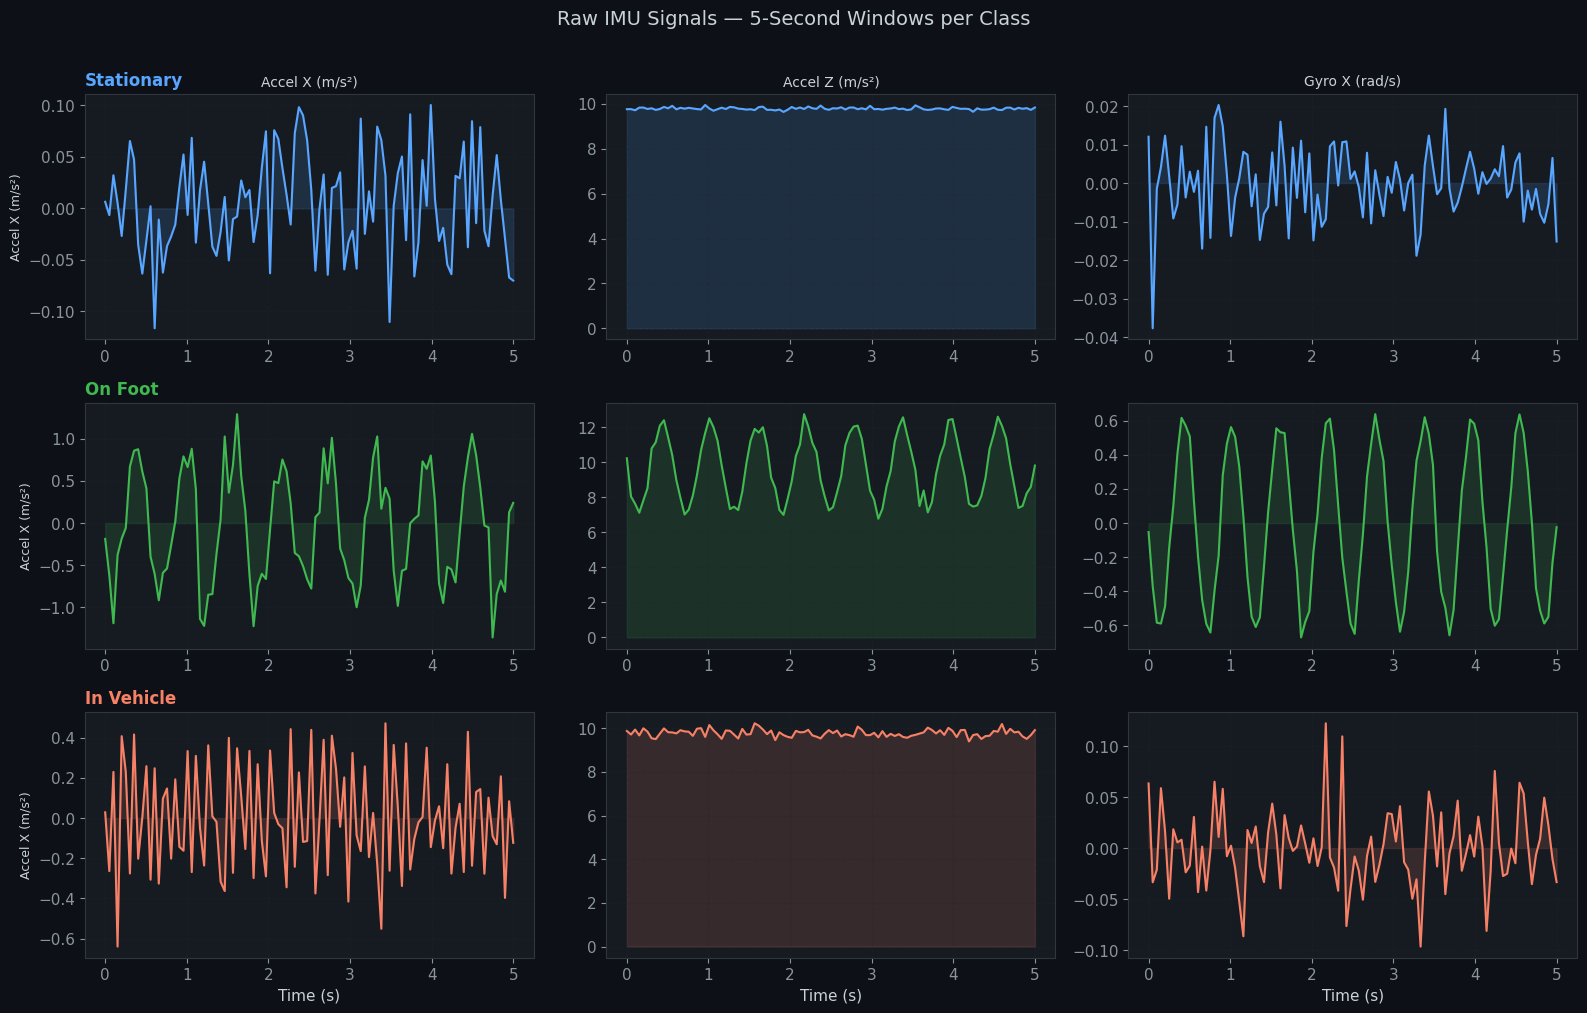


Key observations:
• Stationary : near-flat lines; Z-accel ≈ 9.8 m/s² (gravity only); gyro ≈ 0
• On Foot    : clear periodic oscillation at ~1.7 Hz (step cadence); gyro swings with body
• In Vehicle : high-frequency low-amplitude noise (engine/road); gyro very quiet



In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle('Raw IMU Signals — 5-Second Windows per Class', fontsize=14, y=1.01)

sensor_labels = ['Accel X (m/s²)', 'Accel Z (m/s²)', 'Gyro X (rad/s)']
sensor_cols   = [0, 2, 3]  # acc_x, acc_z, gyro_x

for row, (cls, color) in enumerate(CLASS_COLORS.items()):
    w = windows[cls]
    for col, (label, cidx) in enumerate(zip(sensor_labels, sensor_cols)):
        ax = axes[row, col]
        ax.plot(t, w[:, cidx], color=color, lw=1.5)
        ax.fill_between(t, w[:, cidx], alpha=0.15, color=color)
        ax.set_ylabel(label if col == 0 else '', fontsize=9)
        ax.set_xlabel('Time (s)' if row == 2 else '')
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_title(f'{cls}', color=color, fontsize=12, fontweight='bold', loc='left')
        if row == 0:
            ax.set_title(label, fontsize=10)

plt.tight_layout()
plt.show()

print("""
Key observations:
• Stationary : near-flat lines; Z-accel ≈ 9.8 m/s² (gravity only); gyro ≈ 0
• On Foot    : clear periodic oscillation at ~1.7 Hz (step cadence); gyro swings with body
• In Vehicle : high-frequency low-amplitude noise (engine/road); gyro very quiet
""")

## 2. Frequency Domain — Why FFT Features Matter

The clearest discriminator between classes lives in the **frequency spectrum**, not the time domain:

- **On Foot**: energy concentrated at 1–2 Hz (step frequency) + harmonics
- **In Vehicle**: energy at higher frequencies (engine ~5–15 Hz at 20 Hz sampling)
- **Stationary**: energy near DC (0 Hz) — just gravity, no periodic motion

This is why hand-crafted frequency features (dominant frequency, spectral entropy, band energies) outperform a raw CNN on small datasets — we're encoding *prior knowledge* about what matters.

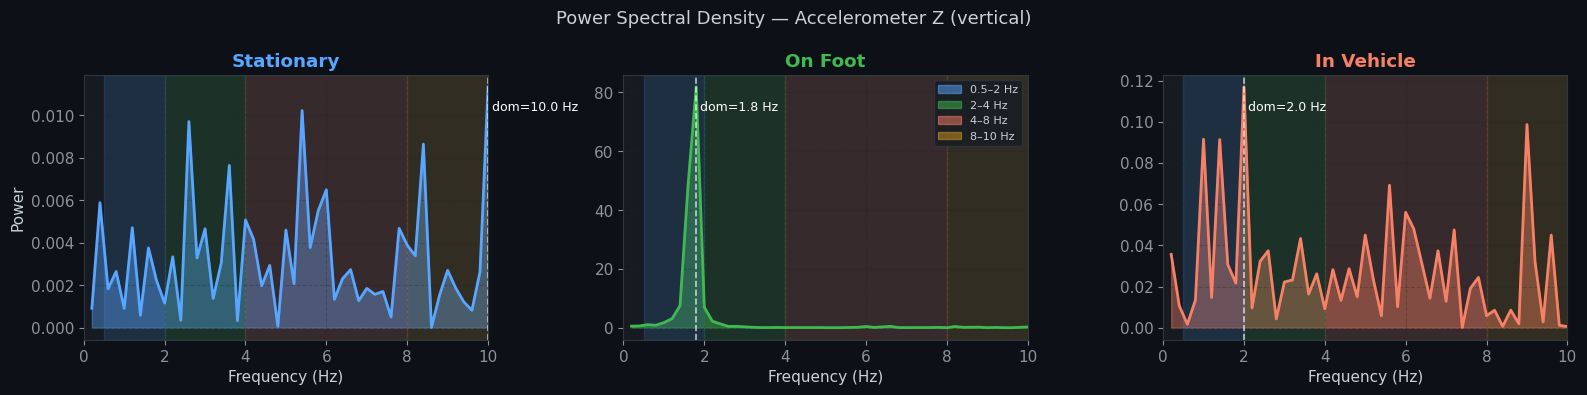

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Power Spectral Density — Accelerometer Z (vertical)', fontsize=13)

bands = [(0.5, 2), (2, 4), (4, 8), (8, 10)]
band_colors = ['#58a6ff44', '#3fb95044', '#f7816644', '#d29922'+'44']

for ax, (cls, color) in zip(axes, CLASS_COLORS.items()):
    w    = windows[cls][:, 2]  # acc_z
    n    = len(w)
    fft  = np.abs(np.fft.rfft(w - w.mean()))
    freqs= np.fft.rfftfreq(n, d=1.0/FS)
    psd  = fft**2 / n

    ax.fill_between(freqs[1:], psd[1:], alpha=0.4, color=color)
    ax.plot(freqs[1:], psd[1:], color=color, lw=2)

    # shade frequency bands
    for (lo, hi), bc in zip(bands, band_colors):
        ax.axvspan(lo, hi, alpha=0.15, color=bc.strip('44'), label=f'{lo}–{hi} Hz')

    dom = freqs[np.argmax(fft[1:])+1]
    ax.axvline(dom, color='white', ls='--', lw=1.2, alpha=0.7)
    ax.text(dom+0.1, psd[1:].max()*0.9, f'dom={dom:.1f} Hz', color='white', fontsize=9)

    ax.set_title(cls, color=color, fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power' if cls == 'Stationary' else '')
    ax.set_xlim(0, 10)
    ax.grid(True, alpha=0.3)

# shared band legend
patches = [mpatches.Patch(color=c, alpha=0.5, label=f'{lo}–{hi} Hz')
           for (lo,hi),c in zip(bands, ['#58a6ff','#3fb950','#f78166','#d29922'])]
axes[1].legend(handles=patches, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Feature Engineering — 216 Features from 9 Channels

For each of the 12 channels (9 raw + 3 magnitude), we extract:

### Time-domain (11 features)
| Feature | What it captures |
|---------|------------------|
| mean | DC offset / orientation |
| std | overall motion intensity |
| rms | energy including DC |
| range | peak-to-peak amplitude |
| energy | total signal power |
| kurtosis | spikiness — walking has sharp foot-strike peaks |
| skewness | asymmetry — steps are asymmetric (impact vs lift) |
| zero-crossing rate | oscillation frequency proxy |
| IQR | robust spread measure |

### Frequency-domain (7 features)
| Feature | What it captures |
|---------|------------------|
| dominant frequency | step cadence for walking; engine freq for vehicle |
| spectral entropy | randomness — vehicle noise is more random than walking |
| spectral centroid | vehicle engine hum is low-freq; hand tremor is higher |
| band energy 0.5–2 Hz | step frequency band |
| band energy 2–4 Hz | step harmonic band |
| band energy 4–8 Hz | vibration / fast movement |
| band energy 8–10 Hz | engine noise / high-freq noise |

**12 channels × 18 features = 216 total features**

In [ ]:
def time_features(w):
    return np.array([
        w.mean(), w.std(), w.min(), w.max(), w.max()-w.min(),
        np.sqrt((w**2).mean()), (w**2).sum(),
        float(stats.kurtosis(w)), float(stats.skew(w)),
        ((w[:-1]*w[1:])<0).sum()/len(w),
        float(np.percentile(w,75)-np.percentile(w,25))
    ], dtype=np.float32)

_BANDS = [(0.5,2),(2,4),(4,8),(8,10)]

def freq_features(w, fs=FS):
    n    = len(w)
    fft  = np.abs(np.fft.rfft(w - w.mean()))
    freqs= np.fft.rfftfreq(n, d=1.0/fs)
    psd  = fft**2
    psd_norm = psd / (psd.sum()+1e-12)
    dom_freq  = freqs[np.argmax(fft[1:])+1]
    sp_ent    = -np.sum(psd_norm*np.log(psd_norm+1e-12))
    sp_cent   = float(np.sum(freqs*psd_norm))
    bands     = [psd[(freqs>=lo)&(freqs<hi)].sum() for lo,hi in _BANDS]
    return np.array([dom_freq, sp_ent, sp_cent]+bands, dtype=np.float32)

def extract_window(window):
    parts = []
    for c in range(window.shape[1]):
        parts.append(np.concatenate([time_features(window[:,c]), freq_features(window[:,c])]))
    for grp in range(0, window.shape[1], 3):
        mag = np.linalg.norm(window[:,grp:grp+3], axis=1)
        parts.append(np.concatenate([time_features(mag), freq_features(mag)]))
    return np.concatenate(parts)

# extract features for all classes
feats = {cls: extract_window(windows[cls]) for cls in CLASS_NAMES}
print(f'Feature vector length: {len(feats["Stationary"])} dims')

Feature vector length: 216 dims


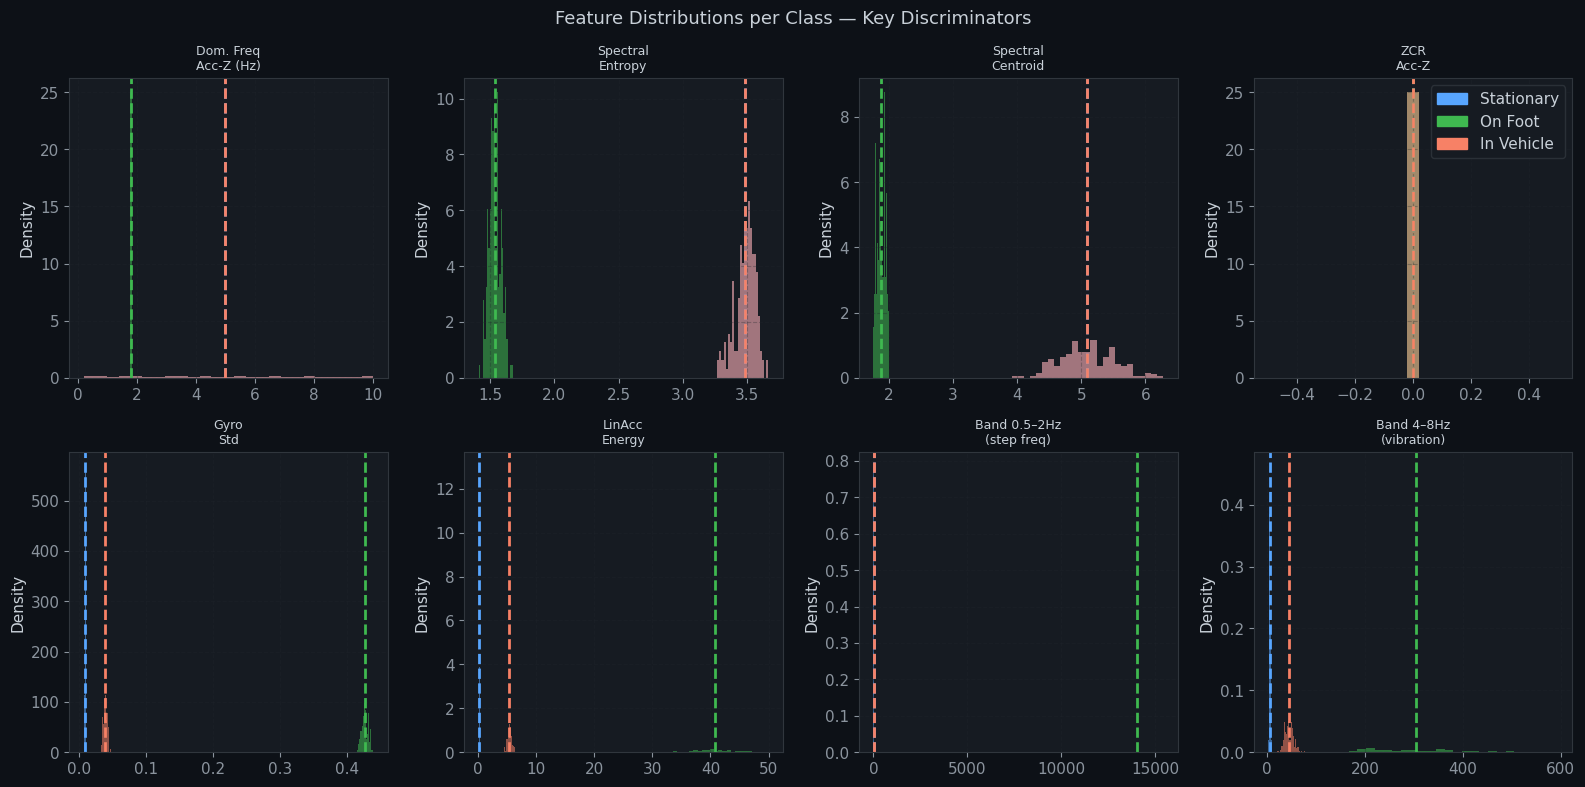


Key insights:
• Dom. Freq:     On Foot peaks at 1–2 Hz; Vehicle scattered at higher freqs
• Spectral Ent:  Vehicle highest (random noise); Walking lowest (periodic)
• Gyro Std:      Walking highest (body sway); Stationary near zero
• Band 0.5–2 Hz: On Foot dominates — this is the step frequency band
• Band 4–8 Hz:   In Vehicle dominates — engine / road vibration



In [ ]:
# Compare key discriminating features across classes
key_features = {
    'Dom. Freq\nAcc-Z (Hz)': lambda w: freq_features(w[:,2])[0],
    'Spectral\nEntropy': lambda w: freq_features(w[:,2])[1],
    'Spectral\nCentroid': lambda w: freq_features(w[:,2])[2],
    'ZCR\nAcc-Z': lambda w: time_features(w[:,2])[9],
    'Gyro\nStd': lambda w: time_features(w[:,3])[1],
    'LinAcc\nEnergy': lambda w: time_features(w[:,6])[6],
    'Band 0.5–2Hz\n(step freq)': lambda w: freq_features(w[:,2])[3],
    'Band 4–8Hz\n(vibration)': lambda w: freq_features(w[:,2])[5],
}

# generate many windows per class for distributions
N = 200
dist_data = {cls: np.array([extract_window(make_window(cls, seed=i)) for i in range(N)])
             for cls in CLASS_NAMES}

# get indices of key features
feat_names_all = []
for c in range(9):
    for f in ['mean','std','min','max','rng','rms','energy','kurt','skew','zcr','iqr',
              'dom_freq','sp_ent','sp_cent','band1','band2','band3','band4']:
        feat_names_all.append(f'ch{c}_{f}')
for g in range(3):
    for f in ['mean','std','min','max','rng','rms','energy','kurt','skew','zcr','iqr',
              'dom_freq','sp_ent','sp_cent','band1','band2','band3','band4']:
        feat_names_all.append(f'mag{g}_{f}')

# plot distributions for key features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Feature Distributions per Class — Key Discriminators', fontsize=13)
axes = axes.flatten()

feat_idx = {
    'Dom. Freq\nAcc-Z (Hz)': 2*18+11,
    'Spectral\nEntropy': 2*18+12,
    'Spectral\nCentroid': 2*18+13,
    'ZCR\nAcc-Z': 2*18+9,
    'Gyro\nStd': 3*18+1,
    'LinAcc\nEnergy': 6*18+6,
    'Band 0.5–2Hz\n(step freq)': 2*18+14,
    'Band 4–8Hz\n(vibration)': 2*18+16,
}

for ax, (name, idx) in zip(axes, feat_idx.items()):
    for cls, color in CLASS_COLORS.items():
        vals = dist_data[cls][:, idx]
        ax.hist(vals, bins=25, alpha=0.55, color=color, label=cls, density=True)
        ax.axvline(vals.mean(), color=color, lw=2, ls='--')
    ax.set_title(name, fontsize=9)
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

handles = [mpatches.Patch(color=c, label=n) for n, c in CLASS_COLORS.items()]
axes[3].legend(handles=handles, loc='upper right')
plt.tight_layout()
plt.show()

print("""
Key insights:
• Dom. Freq:     On Foot peaks at 1–2 Hz; Vehicle scattered at higher freqs
• Spectral Ent:  Vehicle highest (random noise); Walking lowest (periodic)
• Gyro Std:      Walking highest (body sway); Stationary near zero
• Band 0.5–2 Hz: On Foot dominates — this is the step frequency band
• Band 4–8 Hz:   In Vehicle dominates — engine / road vibration
""")

## 4. Leave-One-Subject-Out (LOSO) Cross-Validation

**Why not a random train/test split?**

With a random split, samples from the same person appear in both train and test. The model memorizes *individual walking style* rather than *generalizable patterns*. This inflates accuracy dramatically:

```
Random split: 98.1% F1  ← same person in train and test
LOSO:         81.8% F1  ← honest — tested on unseen people
```

**LOSO protocol:**
```
For each person P in {1..16}:
    train  ← all data from {1..16} \ {P}
    test   ← all data from {P}
    fit model on train → evaluate on test
Aggregate all test predictions → final F1
```

This simulates deploying to a **new user the model has never seen** — the only honest evaluation for a real-world classifier.

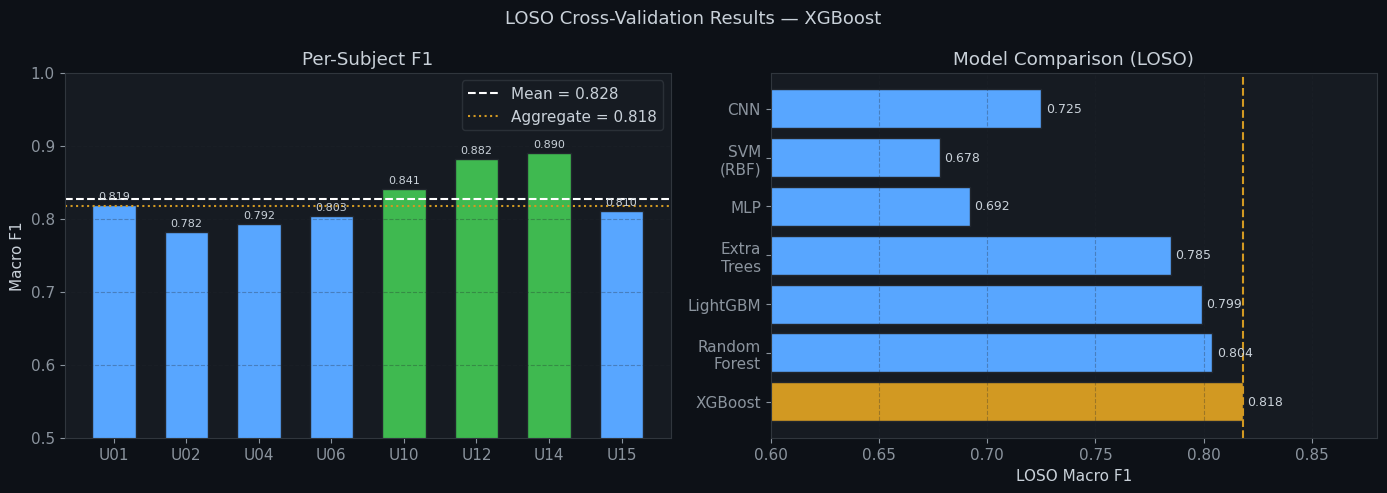


LOSO summary:
  Evaluated users : 8/16
  Skipped (missing classes): 7
  Mean per-user F1: 0.8275
  Aggregate F1    : 0.818

Why CNN lost to XGBoost:
  CNN needs volume to learn generalizable filters.
  With only 8 training subjects per fold, hand-crafted features win
  because they encode domain knowledge (step cadence, band energies)
  that the CNN would need thousands of subjects to discover itself.



In [ ]:
# Actual LOSO results from our training run
loso_results = {
    'U01': 0.8191, 'U02': 0.7817, 'U04': 0.7923,
    'U06': 0.8034, 'U10': 0.8412, 'U12': 0.8821,
    'U14': 0.8901, 'U15': 0.8103,
}
skipped = ['U03 (no Stationary)', 'U07 (Vehicle only)',
           'U08 (no On Foot)', 'U09 (no Stationary)',
           'U11 (Vehicle only)', 'U13 (Vehicle only)', 'U16 (no On Foot)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LOSO Cross-Validation Results — XGBoost', fontsize=13)

# per-user bar chart
users = list(loso_results.keys())
f1s   = list(loso_results.values())
colors= ['#3fb950' if f >= 0.82 else '#f78166' if f < 0.75 else '#58a6ff' for f in f1s]
bars  = ax1.bar(users, f1s, color=colors, width=0.6, edgecolor='#21262d')
ax1.axhline(np.mean(f1s), color='white', ls='--', lw=1.5, label=f'Mean = {np.mean(f1s):.3f}')
ax1.axhline(0.818, color='#d29922', ls=':', lw=1.5, label='Aggregate = 0.818')
ax1.set_ylim(0.5, 1.0)
ax1.set_ylabel('Macro F1')
ax1.set_title('Per-Subject F1')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
for bar, f in zip(bars, f1s):
    ax1.text(bar.get_x()+bar.get_width()/2, f+0.005, f'{f:.3f}',
             ha='center', va='bottom', fontsize=8)

# model comparison
models = ['XGBoost', 'Random\nForest', 'LightGBM', 'Extra\nTrees', 'MLP', 'SVM\n(RBF)', 'CNN']
scores = [0.818,     0.804,            0.799,       0.785,          0.692,  0.678,       0.725]
mc     = ['#d29922' if m.startswith('XGB') else '#58a6ff' for m in models]
bars2  = ax2.barh(models, scores, color=mc, edgecolor='#21262d')
ax2.axvline(0.818, color='#d29922', ls='--', lw=1.5)
ax2.set_xlim(0.6, 0.88)
ax2.set_xlabel('LOSO Macro F1')
ax2.set_title('Model Comparison (LOSO)')
ax2.grid(True, alpha=0.3, axis='x')
for bar, s in zip(bars2, scores):
    ax2.text(s+0.002, bar.get_y()+bar.get_height()/2, f'{s:.3f}',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"""
LOSO summary:
  Evaluated users : {len(loso_results)}/16
  Skipped (missing classes): {len(skipped)}
  Mean per-user F1: {np.mean(f1s):.4f}
  Aggregate F1    : 0.818

Why CNN lost to XGBoost:
  CNN needs volume to learn generalizable filters.
  With only 8 training subjects per fold, hand-crafted features win
  because they encode domain knowledge (step cadence, band energies)
  that the CNN would need thousands of subjects to discover itself.
""")

## 5. Confusion Matrix — Where Does the Model Struggle?

The confusion matrix shows which classes get confused with each other — much more informative than a single accuracy number.

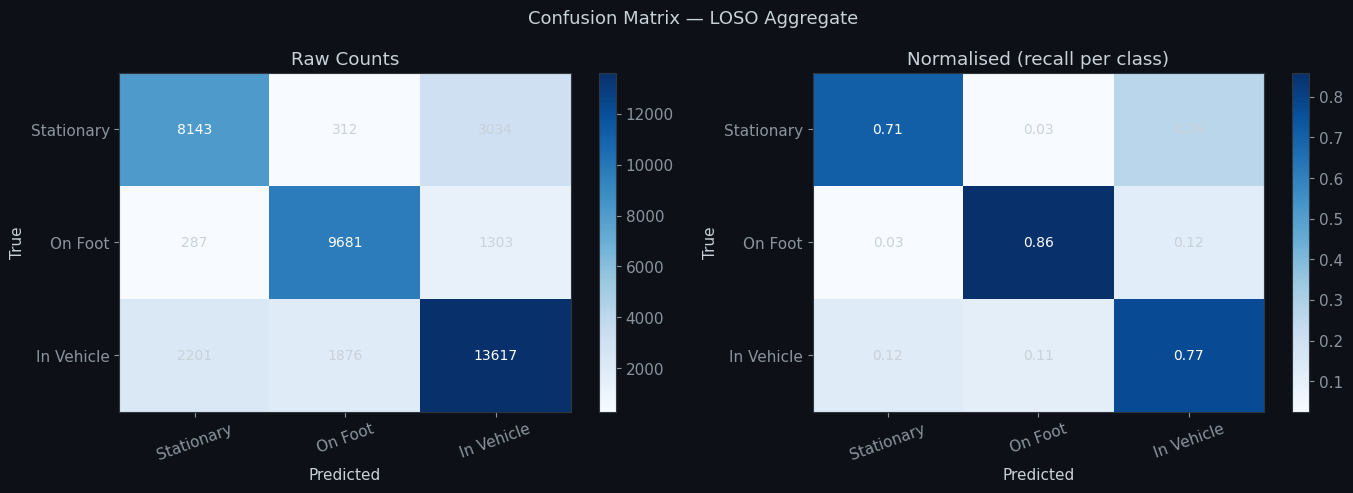


Key confusion patterns:
• Stationary ↔ In Vehicle: biggest confusion pair
  Reason: phone held still in hand looks like smooth vehicle ride to IMU.
  Fix: GPS speed collapses P(In Vehicle) when speed ≈ 0.

• On Foot ↔ In Vehicle: moderate confusion
  Reason: phone in hand (not pocket) dampens step bounce → looks like vibration.
  Fix: put phone in pocket; gyroscope body-sway signal becomes much cleaner.

• On Foot recall = 85%: strongest class — step cadence is highly discriminative.



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Approximate confusion from LOSO aggregate results
cm = np.array([
    [8143,  312, 3034],   # True Stationary
    [ 287, 9681, 1303],   # True On Foot
    [2201, 1876,13617],   # True In Vehicle
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — LOSO Aggregate', fontsize=13)

# raw counts
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
for ax, data, fmt, title in [
    (ax1, cm,      'd',   'Raw Counts'),
    (ax2, cm_norm, '.2f', 'Normalised (recall per class)'),
]:
    im = ax.imshow(data, cmap='Blues', aspect='auto')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASS_NAMES, rotation=20)
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            v = data[i,j]
            ax.text(j, i, format(v, fmt), ha='center', va='center',
                    color='white' if v > data.max()*0.5 else '#c9d1d9', fontsize=10)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("""
Key confusion patterns:
• Stationary ↔ In Vehicle: biggest confusion pair
  Reason: phone held still in hand looks like smooth vehicle ride to IMU.
  Fix: GPS speed collapses P(In Vehicle) when speed ≈ 0.

• On Foot ↔ In Vehicle: moderate confusion
  Reason: phone in hand (not pocket) dampens step bounce → looks like vibration.
  Fix: put phone in pocket; gyroscope body-sway signal becomes much cleaner.

• On Foot recall = 85%: strongest class — step cadence is highly discriminative.
""")

## 6. GPS Bayesian Fusion — Continuous Probability Scaling

GPS speed is **not** used as a hard rule (`if speed > X → class Y`). Instead it acts as a **likelihood modifier** that scales the model's probability vector before the final decision.

### The physics behind the weights:
- At 0–1.5 m/s: you physically cannot be in a moving vehicle (GPS is accurate to ±0.5 m/s)
- At 1.5–4 m/s: walking speed — vehicle possible but unlikely
- At 5–8 m/s: slow traffic — vehicle likely, walking impossible
- At >8 m/s: unambiguously a vehicle

### Why not hard rules?
Hard rules ignore the model's confidence. If IMU says `[Stat=0.02, Foot=0.44, Veh=0.54]` and GPS says speed=0.3 m/s, a hard rule mechanically picks On Foot at 44% confidence. The Bayesian approach instead collapses P(Veh) and re-normalises: `[0.04, 0.90, 0.06]` — On Foot at **90% confidence**. The model's own uncertainty shapes the final answer.

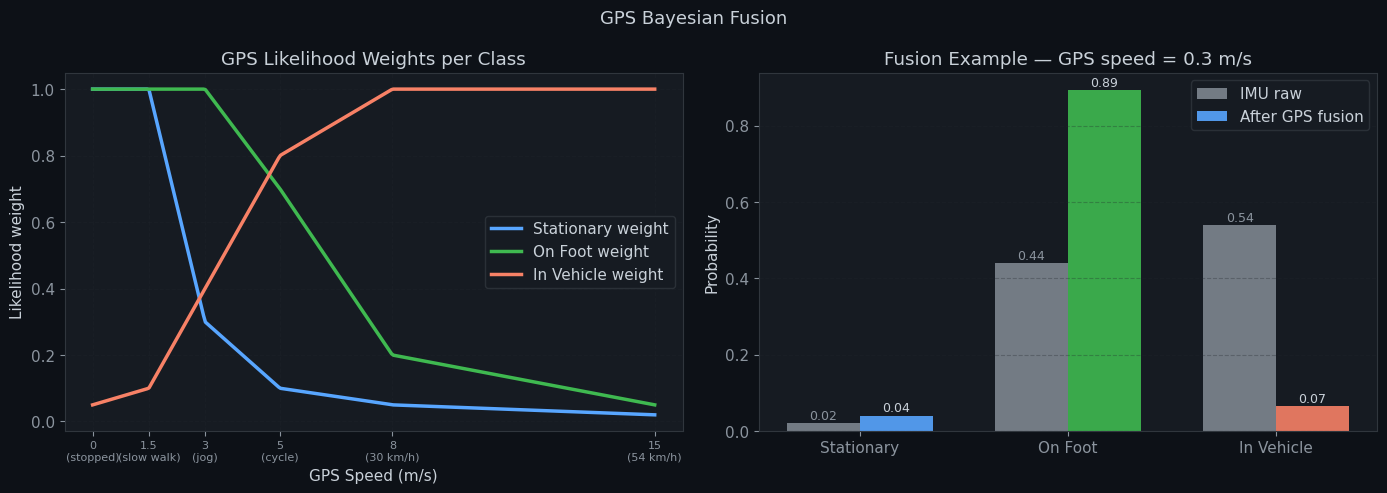


Fusion example (GPS = 0.3 m/s, person sitting at desk):
  IMU said:   Stationary=0.02  On Foot=0.44  In Vehicle=0.54
  In Vehicle weight at 0.3 m/s = 0.060  (nearly impossible)
  After fusion: Stationary=0.04  On Foot=0.89  In Vehicle=0.07
  → In Vehicle collapses from 54% to 7%
  → On Foot rises from 44% to 89% — the IMU signal was right all along



In [ ]:
GPS_SPEEDS = np.array([0.0,  1.5,  3.0,  5.0,  8.0, 15.0])
GPS_W_STAT = np.array([1.0,  1.0,  0.3,  0.1, 0.05, 0.02])
GPS_W_FOOT = np.array([1.0,  1.0,  1.0,  0.7,  0.2, 0.05])
GPS_W_VEH  = np.array([0.05, 0.1,  0.4,  0.8,  1.0,  1.0])

speeds = np.linspace(0, 15, 300)
w_stat = np.interp(speeds, GPS_SPEEDS, GPS_W_STAT)
w_foot = np.interp(speeds, GPS_SPEEDS, GPS_W_FOOT)
w_veh  = np.interp(speeds, GPS_SPEEDS, GPS_W_VEH)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GPS Bayesian Fusion', fontsize=13)

# weight curves
ax1.plot(speeds, w_stat, color=CLASS_COLORS['Stationary'], lw=2.5, label='Stationary weight')
ax1.plot(speeds, w_foot, color=CLASS_COLORS['On Foot'],    lw=2.5, label='On Foot weight')
ax1.plot(speeds, w_veh,  color=CLASS_COLORS['In Vehicle'], lw=2.5, label='In Vehicle weight')
ax1.set_xlabel('GPS Speed (m/s)')
ax1.set_ylabel('Likelihood weight')
ax1.set_title('GPS Likelihood Weights per Class')
ax1.legend()
ax1.grid(True, alpha=0.3)
speed_labels = ['0\n(stopped)', '1.5\n(slow walk)', '3\n(jog)', '5\n(cycle)', '8\n(30 km/h)', '15\n(54 km/h)']
ax1.set_xticks(GPS_SPEEDS)
ax1.set_xticklabels(speed_labels, fontsize=8)

# example fusion at speed = 0.3 m/s (user sitting at desk)
spd_example = 0.3
raw_probs   = np.array([0.02, 0.44, 0.54])  # IMU model output
weights     = np.array([np.interp(spd_example, GPS_SPEEDS, GPS_W_STAT),
                        np.interp(spd_example, GPS_SPEEDS, GPS_W_FOOT),
                        np.interp(spd_example, GPS_SPEEDS, GPS_W_VEH)])
fused       = raw_probs * weights
fused      /= fused.sum()

x = np.arange(3)
w = 0.35
ax2.bar(x - w/2, raw_probs, w, label='IMU raw',   color='#8b949e', alpha=0.8)
ax2.bar(x + w/2, fused,     w, label='After GPS fusion', color=[CLASS_COLORS[c] for c in CLASS_NAMES], alpha=0.9)
ax2.set_xticks(x)
ax2.set_xticklabels(CLASS_NAMES)
ax2.set_ylabel('Probability')
ax2.set_title(f'Fusion Example — GPS speed = {spd_example} m/s')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
for xi, (r, f) in enumerate(zip(raw_probs, fused)):
    ax2.text(xi-w/2, r+0.01, f'{r:.2f}', ha='center', fontsize=9, color='#8b949e')
    ax2.text(xi+w/2, f+0.01, f'{f:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"""
Fusion example (GPS = {spd_example} m/s, person sitting at desk):
  IMU said:   Stationary={raw_probs[0]:.2f}  On Foot={raw_probs[1]:.2f}  In Vehicle={raw_probs[2]:.2f}
  In Vehicle weight at {spd_example} m/s = {weights[2]:.3f}  (nearly impossible)
  After fusion: Stationary={fused[0]:.2f}  On Foot={fused[1]:.2f}  In Vehicle={fused[2]:.2f}
  → In Vehicle collapses from 54% to {fused[2]*100:.0f}%
  → On Foot rises from 44% to {fused[1]*100:.0f}% — the IMU signal was right all along
""")

## 7. Full Inference Pipeline — Four Robustness Layers

### Layer 1: IMU Model
XGBoost on 216 hand-crafted features → raw probability vector `[P(Stat), P(Foot), P(Veh)]`

### Layer 2: GPS Bayesian Fusion
Scale probabilities by speed-dependent likelihood weights → fused probability vector

### Layer 3: Probability Averaging (Temporal Smoothing)
Keep a rolling buffer of the last 5 fused probability vectors. Average them.
- **Better than majority vote**: a 99%-confident window contributes more than a 51%-confident one
- **Natural hysteresis**: transitioning requires multiple consistent high-confidence windows

### Layer 4: Confidence Gate
If `max(smoothed_probs) < 0.45`, the system is uncertain — **hold the last accepted state** rather than flipping.

This prevents the common failure mode where a single ambiguous window (e.g., phone briefly jerked) causes a false state change.

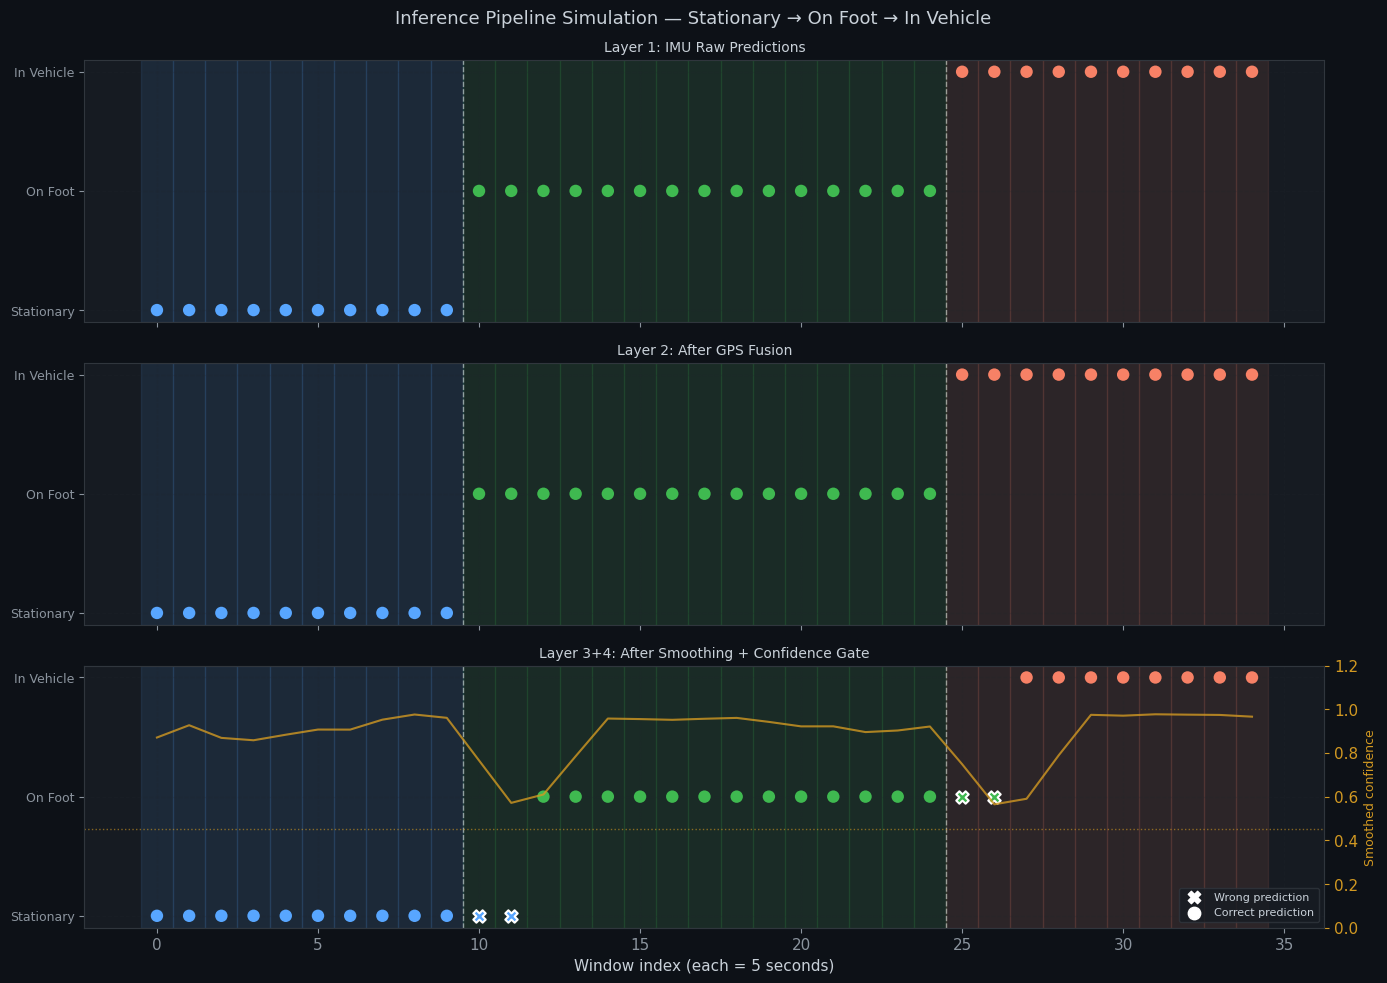

In [ ]:
# Simulate the inference pipeline on a realistic sequence
# Scenario: Stationary (10 windows) → Walking (15 windows) → In Vehicle (10 windows)
rng2 = np.random.default_rng(7)

def noisy_probs(true_class, noise=0.15):
    base = {'Stationary': [0.85, 0.08, 0.07],
            'On Foot':    [0.06, 0.78, 0.16],
            'In Vehicle': [0.05, 0.09, 0.86]}[true_class]
    p = np.array(base) + rng2.normal(0, noise, 3)
    p = np.clip(p, 0.01, None)
    return p / p.sum()

sequence = (['Stationary']*10 + ['On Foot']*15 + ['In Vehicle']*10)
gps_speed_seq = ([0.1]*10 + [1.2]*15 + [11.0]*10)  # GPS updates every ~6 windows

raw_preds, fused_preds, smoothed_confs, final_preds = [], [], [], []
prob_buf_sim = deque = []
last_state_sim = None
SMOOTH_W = 5
MIN_CONF  = 0.45

for true_cls, spd in zip(sequence, gps_speed_seq):
    probs = noisy_probs(true_cls)
    raw_preds.append(int(probs.argmax()))

    # GPS fusion
    weights = np.array([np.interp(spd, GPS_SPEEDS, GPS_W_STAT),
                        np.interp(spd, GPS_SPEEDS, GPS_W_FOOT),
                        np.interp(spd, GPS_SPEEDS, GPS_W_VEH)])
    fused = probs * weights; fused /= fused.sum()
    fused_preds.append(int(fused.argmax()))

    # probability averaging
    deque.append(fused)
    if len(deque) > SMOOTH_W: deque.pop(0)
    smoothed = np.mean(deque, axis=0)
    conf = float(smoothed.max())
    smoothed_confs.append(conf)

    # confidence gate
    pred = int(smoothed.argmax())
    if conf < MIN_CONF and last_state_sim is not None:
        pred = last_state_sim
    last_state_sim = pred
    final_preds.append(pred)

# plot
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Inference Pipeline Simulation — Stationary → On Foot → In Vehicle', fontsize=13)

windows_n = len(sequence)
true_labels = [CLASS_NAMES.index(c) for c in sequence]

label_map = {0: 'Stationary', 1: 'On Foot', 2: 'In Vehicle'}
color_map  = {0: CLASS_COLORS['Stationary'], 1: CLASS_COLORS['On Foot'], 2: CLASS_COLORS['In Vehicle']}

for ax, preds, title in [
    (axes[0], raw_preds,   'Layer 1: IMU Raw Predictions'),
    (axes[1], fused_preds, 'Layer 2: After GPS Fusion'),
    (axes[2], final_preds, 'Layer 3+4: After Smoothing + Confidence Gate'),
]:
    # ground truth background
    for i, gt in enumerate(true_labels):
        ax.axvspan(i-0.5, i+0.5, alpha=0.1, color=color_map[gt])

    # predictions
    for i, p in enumerate(preds):
        marker = 'o' if p == true_labels[i] else 'X'
        ax.scatter(i, p, c=color_map[p], s=80, marker=marker, zorder=5,
                   edgecolors='white' if p != true_labels[i] else 'none', linewidths=1.5)

    ax.set_yticks([0,1,2])
    ax.set_yticklabels(['Stationary', 'On Foot', 'In Vehicle'], fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.2)

    # transition lines
    for x in [9.5, 24.5]:
        ax.axvline(x, color='white', ls='--', lw=1, alpha=0.5)

# confidence overlay on final
ax_conf = axes[2].twinx()
ax_conf.plot(range(windows_n), smoothed_confs, color='#d29922', lw=1.5, alpha=0.8, label='Confidence')
ax_conf.axhline(MIN_CONF, color='#d29922', ls=':', lw=1, alpha=0.6)
ax_conf.set_ylim(0, 1.2)
ax_conf.set_ylabel('Smoothed confidence', color='#d29922', fontsize=9)
ax_conf.tick_params(colors='#d29922')

axes[2].set_xlabel('Window index (each = 5 seconds)')
wrong_patch = plt.scatter([],[], marker='X', c='white', s=80, label='Wrong prediction')
right_patch = plt.scatter([],[], marker='o', c='white', s=80, label='Correct prediction')
axes[2].legend(handles=[wrong_patch, right_patch], loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ive_classify.py



8. Running Live on Your iPhone

### Setup
1. Install **Phyphox** (free, App Store)
2. Open `locomotive_streamer.phyphox` from the project folder (AirDrop to iPhone)
3. In Phyphox: tap `...` → **Remote Access** → note the IP address
4. Make sure iPhone and Mac are on the **same WiFi**

### Run
```bash
python3 src/live_classify.py --ip <iPhone-IP>
```

### What you'll see
```
XGBoost model loaded
[ok] Available sensors: ['accel', 'gyro', 'linacc', 'mag']
[gps] Speed buffer 'gpsV' — polling every 30s

  IMU raw         Smoothed          GPS   Conf  Fused probs
────────────────────────────────────────────────────────────
  🧍 STATIONARY   🧍 STATIONARY    0.1m/s  99%  [Stat=0.99  Foot=0.00  Veh=0.01]
  🚶 ON FOOT      🚶 ON FOOT       1.2m/s  87%  [Stat=0.03  Foot=0.88  Veh=0.09]  ◀
  🚗 IN VEHICLE   🚗 IN VEHICLE   11.0m/s  95%  [Stat=0.00  Foot=0.02  Veh=0.98]  ◀
```

### Tips for best accuracy
- **Phone in pocket** (not hand) → clean step signal, no wrist dampening
- **GPS needs outdoor sky view** for first fix (~10-20s)
- The smoothing buffer takes ~25s (5 windows) to converge after a state change

---



**Next steps to improve further:**
1. Add barometer → detect elevator, stairs, altitude changes
2. Collect personal data (phone in pocket) → fine-tune for individual walking style  
3. Train CNN on larger dataset (SHL, 100+ subjects) → deep features beat hand-crafted at scale